In [1]:
from langgraph.graph import StateGraph,START,END

from typing import TypedDict


In [48]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    
    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float
    summary: dict

In [39]:
def calculate_strike_rate(state:BatsmanState)->BatsmanState:
    #strike_rate = (runs/balls)*100
    sr = (state['runs']/state['balls'])*100
    
    return {'strike_rate': sr}

In [40]:
def calculate_balls_per_boundary(state:BatsmanState)->BatsmanState:
    #balls_per_boundary = balls/boundaries
    bpb = state['balls']/(state['fours']+state['sixes'])
    return {'balls_per_boundary': bpb}

In [41]:
def calculate_boundary_percentage(state:BatsmanState)->BatsmanState:
    bp = ((state['fours']+state['sixes'])/state['balls'])*100
    return {'boundary_percentage': bp}

In [47]:
def calculate_summary(state:BatsmanState)->BatsmanState:
    state['summary'] = {
        'strike_rate': state['strike_rate'],
        'balls_per_boundary': state['balls_per_boundary'],
        'boundary_percentage': state['boundary_percentage']
    }
    return {'summary': state['summary']}

In [49]:
graph = StateGraph(BatsmanState)

#nodes
graph.add_node('calculate_strike_rate',calculate_strike_rate)
graph.add_node('calculate_balls_per_boundary',calculate_balls_per_boundary)
graph.add_node('calculate_boundary_percentage',calculate_boundary_percentage)
graph.add_node('calculate_summary',calculate_summary)

#edges
graph.add_edge(START,'calculate_strike_rate')
graph.add_edge(START,'calculate_balls_per_boundary')
graph.add_edge(START,'calculate_boundary_percentage')

graph.add_edge('calculate_strike_rate','calculate_summary')
graph.add_edge('calculate_balls_per_boundary','calculate_summary')
graph.add_edge('calculate_boundary_percentage','calculate_summary')

graph.add_edge('calculate_summary',END)
#compile

workflow = graph.compile()

In [50]:
initial_state = {
    'runs': 120,
    'balls': 80,
    'fours': 10,
    'sixes': 5
}
workflow.invoke(initial_state)



{'runs': 120,
 'balls': 80,
 'fours': 10,
 'sixes': 5,
 'strike_rate': 150.0,
 'balls_per_boundary': 5.333333333333333,
 'boundary_percentage': 18.75,
 'summary': {'strike_rate': 150.0,
  'balls_per_boundary': 5.333333333333333,
  'boundary_percentage': 18.75}}

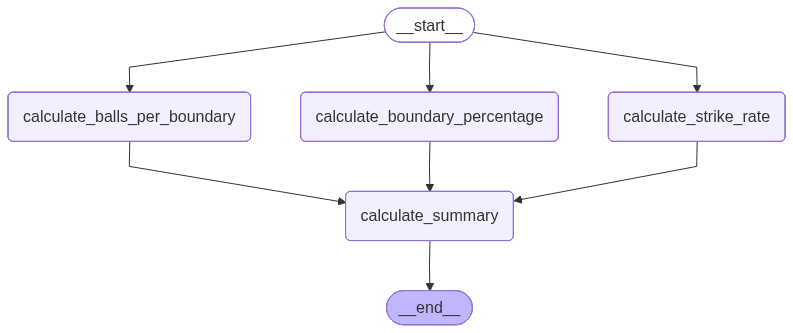

In [51]:
#visualize the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())